# Modelamiento - Riesgo Crediticio

**Objetivo:** entrenar y comparar una batería de modelos supervisados de clasificación sobre `Pago_atiempo`, usando `preparar_datos` de `src/ft_engineering.py` como única fuente de datos preparados (ya excluye `puntaje` por la fuga confirmada en `ft_engineering.ipynb`).

## Carga de datos preparados

Se importa `preparar_datos` y se llama pasando `puntaje` en `columnas_excluidas` — es la única columna con fuga confirmada (AUC univariado = 1.0, separación perfecta). `saldo_*` quedó como dudosa pero no confirmada, así que no se excluye acá.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.ft_engineering import preparar_datos

RUTA_EXCEL = RAIZ / "data" / "raw" / "Base_de_datos.xlsx"
COLUMNAS_EXCLUIDAS_POR_FUGA = ["puntaje"]

X_train, X_test, y_train, y_test, preprocesador = preparar_datos(
    RUTA_EXCEL, columnas_excluidas=COLUMNAS_EXCLUIDAS_POR_FUGA, test_size=0.2, random_state=42,
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (8610, 32) | X_test: (2153, 32)


## Qué métrica importa más acá

El desbalance de clases visto en el paso 01 es fuerte: ~95.25% de los créditos se pagan a tiempo, ~4.75% no. Con ese desbalance, **el accuracy engaña**: un modelo que prediga siempre "pagó a tiempo" ya acierta ~95% de las veces sin haber aprendido nada.

Para **comparar modelos entre sí** (que es lo que se hace en este notebook, antes de fijar un umbral de decisión operativo) la métrica más relevante es **ROC-AUC**: mide qué tan bien separa el modelo las dos clases en todos los umbrales posibles, es independiente del punto de corte que se elija después, y no se infla artificialmente por el desbalance como sí le pasa al accuracy. Por eso el ranking de modelos de este notebook se ordena por ROC-AUC de test, y la validación cruzada también usa `scoring="roc_auc"`.

Dicho esto, ROC-AUC no cierra la discusión: una vez elegido el modelo y fijado un umbral operativo, lo que más importa en un problema de riesgo crediticio es el **recall de la clase 0** (detectar los créditos que realmente no se van a pagar a tiempo) — un falso negativo ahí (decir que va a pagar cuando no va a pagar) le cuesta plata real al negocio, mientras que un falso positivo (rechazar a alguien que sí iba a pagar) es una oportunidad perdida, más barata. Ese análisis de costo de error se retoma en la sección de selección final del modelo.

## `build_model` y `summarize_classification`

Dos funciones reutilizables: una arma y ajusta el pipeline completo (preprocesador + estimador), la otra evalúa cualquier pipeline ya ajustado sobre cualquier conjunto, devolviendo un diccionario con las 5 métricas — así el resto del notebook solo llama a estas dos funciones, sin repetir lógica de entrenamiento/evaluación por cada modelo.

In [2]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline


def build_model(estimador, preprocesador, X_train, y_train):
    """Arma un Pipeline (preprocesador + estimador) y lo ajusta sobre train.

    Se clona el preprocesador antes de armar el Pipeline para que cada
    modelo tenga su propia instancia ajustada de forma independiente, sin
    compartir estado con otros pipelines que usen el mismo preprocesador
    base.

    Parameters
    ----------
    estimador : sklearn estimator
        El clasificador a entrenar (sin ajustar).
    preprocesador : sklearn.compose.ColumnTransformer
        El preprocesador (sin ajustar) devuelto por preparar_datos.
    X_train, y_train : array-like
        Datos de entrenamiento.

    Returns
    -------
    sklearn.pipeline.Pipeline
        El pipeline (preprocesador + estimador) ya ajustado.
    """
    pipeline = Pipeline(steps=[
        ("preprocesador", clone(preprocesador)),
        ("modelo", estimador),
    ])
    pipeline.fit(X_train, y_train)
    return pipeline


def summarize_classification(nombre, modelo, X, y, conjunto):
    """Evalúa un pipeline ya ajustado y resume 5 métricas de clasificación.

    Usa predict_proba para el score de AUC cuando el estimador lo soporta
    (la mayoría de los clasificadores de sklearn) y decision_function
    cuando no (por ejemplo, algunas configuraciones de SVC).

    Parameters
    ----------
    nombre : str
        Nombre identificador del modelo, para la tabla comparativa.
    modelo : sklearn estimator o Pipeline
        Modelo ya ajustado.
    X, y : array-like
        Datos sobre los que evaluar.
    conjunto : str
        Nombre del conjunto evaluado (por ejemplo "train" o "test"), para
        dejar explícito sobre qué datos se calculó cada métrica.

    Returns
    -------
    dict
        {"modelo", "conjunto", "accuracy", "precision", "recall", "f1", "roc_auc"}
    """
    y_pred = modelo.predict(X)

    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X)[:, 1]
    elif hasattr(modelo, "decision_function"):
        y_score = modelo.decision_function(X)
    else:
        y_score = y_pred

    return {
        "modelo": nombre,
        "conjunto": conjunto,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_score),
    }

## Prueba con una regresión logística simple

Se ajusta con `build_model` y se evalúa con `summarize_classification` sobre train y sobre test, para confirmar que las dos funciones andan antes de correr toda la batería de modelos.

In [3]:
from sklearn.linear_model import LogisticRegression

modelo_prueba = build_model(LogisticRegression(max_iter=1000, random_state=42), preprocesador, X_train, y_train)

resultado_train = summarize_classification("LogisticRegression (prueba)", modelo_prueba, X_train, y_train, "train")
resultado_test = summarize_classification("LogisticRegression (prueba)", modelo_prueba, X_test, y_test, "test")

pd.DataFrame([resultado_train, resultado_test])

,modelo,conjunto,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression (prueba),train,0.952962,0.953361,0.999512,0.975891,0.697071
1,LogisticRegression (prueba),test,0.953089,0.953067,1.000000,0.975970,0.665228


**Nota sobre esta primera prueba.** `precision`/`recall`/`f1` se calculan con el `pos_label` por defecto de sklearn (clase `1` = pagó a tiempo, la mayoritaria). El recall de esa clase da ≈1.0 — el modelo está prediciendo "pagó a tiempo" para casi todo el mundo, que es exactamente la trampa del desbalance que ya se advirtió más arriba: con 95% de una sola clase, hasta un modelo que casi no distingue nada saca recall/precision altísimos en la clase mayoritaria. El `roc_auc` (0.665-0.697, bastante más bajo) es mucho más honesto acá. El desempeño sobre la clase minoritaria (`0`, no pagó — la que le importa al negocio) se examina más adelante con las matrices de confusión, donde se ve el error por clase de forma explícita en vez de agregado en una sola cifra.

# Batería de modelos supervisados

Seis algoritmos, todos con `random_state=42` donde el estimador lo acepta (KNN no tiene ese parámetro). Para los que soportan `class_weight` (LogisticRegression, DecisionTree, RandomForest — GradientBoosting, XGBoost y KNN no lo soportan en su API de sklearn) se entrena además una variante `class_weight="balanced"`, con el sufijo `" (balanceado)"`.

In [4]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

ESTIMADORES = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "LogisticRegression (balanceado)": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "DecisionTree (balanceado)": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "RandomForest (balanceado)": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
}

resultados = []
pipelines_entrenados = {}

for nombre, estimador in ESTIMADORES.items():
    pipeline = build_model(estimador, preprocesador, X_train, y_train)
    pipelines_entrenados[nombre] = pipeline
    resultados.append(summarize_classification(nombre, pipeline, X_train, y_train, "train"))
    resultados.append(summarize_classification(nombre, pipeline, X_test, y_test, "test"))
    print(f"{nombre}: entrenado")

LogisticRegression: entrenado
DecisionTree: entrenado


RandomForest: entrenado


GradientBoosting: entrenado
XGBoost: entrenado


KNN: entrenado
LogisticRegression (balanceado): entrenado
DecisionTree (balanceado): entrenado


RandomForest (balanceado): entrenado


## Tabla comparativa, ordenada por ROC-AUC de test

Una fila por modelo, con las métricas de train y de test lado a lado (para que quede explícito sobre qué conjunto se calculó cada una), más la diferencia entre el AUC de train y el de test como señal de sobreajuste de un vistazo.

In [5]:
tabla_larga = pd.DataFrame(resultados)

df_train = tabla_larga[tabla_larga["conjunto"] == "train"].set_index("modelo")
df_test = tabla_larga[tabla_larga["conjunto"] == "test"].set_index("modelo")

comparacion = pd.DataFrame({
    "accuracy_train": df_train["accuracy"], "accuracy_test": df_test["accuracy"],
    "precision_train": df_train["precision"], "precision_test": df_test["precision"],
    "recall_train": df_train["recall"], "recall_test": df_test["recall"],
    "f1_train": df_train["f1"], "f1_test": df_test["f1"],
    "roc_auc_train": df_train["roc_auc"], "roc_auc_test": df_test["roc_auc"],
})
comparacion["diferencia_auc_train_test"] = (comparacion["roc_auc_train"] - comparacion["roc_auc_test"]).round(4)
comparacion = comparacion.round(4).sort_values("roc_auc_test", ascending=False)
comparacion

,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test,roc_auc_train,roc_auc_test,diferencia_auc_train_test
modelo,,,,,,,,,,,
GradientBoosting,0.9584,0.9536,0.9582,0.9544,1.0000,0.9990,0.9786,0.9762,0.8859,0.6890,0.1969
XGBoost,0.9999,0.9526,0.9999,0.9552,1.0000,0.9971,0.9999,0.9757,1.0000,0.6733,0.3267
LogisticRegression,0.9530,0.9531,0.9534,0.9531,0.9995,1.0000,0.9759,0.9760,0.6971,0.6652,0.0318
LogisticRegression (balanceado),0.6678,0.6484,0.9731,0.9661,0.6698,0.6538,0.7934,0.7799,0.7044,0.6637,0.0407
RandomForest,1.0000,0.9526,1.0000,0.9526,1.0000,1.0000,1.0000,0.9757,1.0000,0.6594,0.3406
RandomForest (balanceado),1.0000,0.9545,1.0000,0.9548,1.0000,0.9995,1.0000,0.9767,1.0000,0.6561,0.3439
DecisionTree (balanceado),0.6667,0.6289,0.9795,0.9637,0.6639,0.6343,0.7914,0.7651,0.7536,0.5981,0.1555
DecisionTree,0.9555,0.9526,0.9557,0.9539,0.9996,0.9985,0.9772,0.9757,0.6717,0.5852,0.0865
KNN,0.9526,0.9522,0.9531,0.9526,0.9994,0.9995,0.9757,0.9755,0.8644,0.5575,0.3069


## Validación cruzada de los 3 mejores (por ROC-AUC de test)

5 folds estratificados, `scoring="roc_auc"`, corridos **solo sobre `X_train`** (la CV es para elegir/confirmar el modelo, el test queda aparte para la evaluación final).

In [6]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score

TOP_3 = comparacion.index[:3].tolist()
print("Top 3 por roc_auc de test:", TOP_3)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = []
for nombre in TOP_3:
    pipeline_cv = Pipeline(steps=[("preprocesador", clone(preprocesador)), ("modelo", clone(ESTIMADORES[nombre]))])
    scores = cross_val_score(pipeline_cv, X_train, y_train, cv=skf, scoring="roc_auc")
    resultados_cv.append({
        "modelo": nombre,
        "cv_auc_media": round(scores.mean(), 4),
        "cv_auc_std": round(scores.std(), 4),
        "cv_scores": [round(s, 4) for s in scores],
    })

tabla_cv = pd.DataFrame(resultados_cv)
tabla_cv

Top 3 por roc_auc de test: ['GradientBoosting', 'XGBoost', 'LogisticRegression']


/Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/pf-riesgo-venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/pf-riesgo-venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/pf-riesgo-venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/pf-riesgo-venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/pf-riesgo-venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/pf-riesgo-venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,modelo,cv_auc_media,cv_auc_std,cv_scores
0,GradientBoosting,0.7068,0.0208,"[0.7177, 0.6836, 0.6845, 0.7097, 0.7385]"
1,XGBoost,0.6561,0.0190,"[0.6356, 0.6544, 0.6889, 0.6623, 0.6394]"
2,LogisticRegression,0.6692,0.0298,"[0.6166, 0.6577, 0.6806, 0.6931, 0.698]"


**Interpretación: quién sobreajusta y quién se sostiene en CV.**

- **Sobreajustan fuerte:** `RandomForest`/`RandomForest (balanceado)` (AUC train = 1.0000 contra test ≈0.656-0.659, diferencia ≈0.34) y `XGBoost` (train = 1.0000, test = 0.6733, diferencia ≈0.33) memorizan el train casi perfectamente y pierden un tercio de AUC al pasar a test. `KNN` también (diferencia ≈0.31) — con 32 columnas transformadas, sus "vecinos" en train terminan siendo casi el propio punto.
- **Sobreajusta, pero menos, y sigue siendo el mejor en test y en CV:** `GradientBoosting` (train 0.8859, test 0.6890, diferencia ≈0.20). En cross-validation da la media más alta de los tres candidatos (0.7068 ± 0.0208), por encima incluso de su propio AUC de test — indicio de que el 0.689 de test no es un techo optimista, sino un valor consistente con lo que el modelo rinde en distintos folds.
- **Prácticamente no sobreajustan:** `LogisticRegression` y su variante balanceada (diferencia ≈0.03-0.04 entre train y test). Son los más estables, pero también los que menos AUC alcanzan — la simpleza del modelo lineal no le saca todo el jugo a la relación entre variables.
- **`class_weight="balanced"` no mejora el AUC** en ninguno de los tres casos que lo soportan (compárese cada modelo base contra su versión balanceada): sube mucho el recall/precision reportados con el `pos_label` por defecto (clase 1) a costa de hundir el accuracy (LogisticRegression balanceado cae a 0.65, DecisionTree balanceado a 0.63), pero el ROC-AUC (que no depende del umbral) queda prácticamente igual o levemente peor. Tiene sentido: `class_weight` cambia dónde el modelo pone el umbral de decisión, no qué tan bien separa las clases en el fondo.

En conjunto: `GradientBoosting` es, hoy, el candidato más sólido — mejor test, mejor CV, y un sobreajuste presente pero no descontrolado como el de `RandomForest`/`XGBoost`.

# Gráficos comparativos

Todos los gráficos de esta sección se guardan como PNG en `reports/figuras/`.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
REPORTS_FIGURAS = RAIZ / "reports" / "figuras"
REPORTS_FIGURAS.mkdir(parents=True, exist_ok=True)
print("Carpeta de figuras:", REPORTS_FIGURAS)

Carpeta de figuras: /Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/reports/figuras


## Curvas ROC (todos los modelos, test)

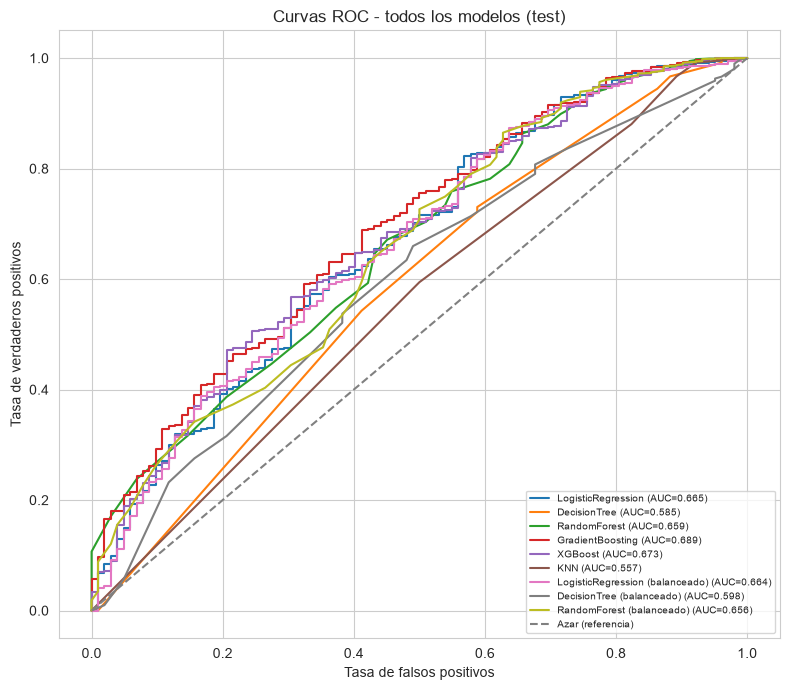

In [8]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))
for nombre, pipeline in pipelines_entrenados.items():
    y_score = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (referencia)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - todos los modelos (test)")
plt.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig(REPORTS_FIGURAS / "curvas_roc.png", dpi=150)
plt.show()

**Interpretación.** Todas las curvas se despegan de la diagonal, pero ninguna se acerca a la esquina superior izquierda — consistente con los AUC de test ya vistos (0.56-0.69, ninguno "excelente"). `GradientBoosting` queda visiblemente por encima del resto en la mayor parte del rango de FPR, confirmando de forma visual lo que ya decía la tabla comparativa.

## Curvas Precision-Recall (todos los modelos, test)

Con 95%/5% de desbalance, la ROC puede verse "bien" aunque el modelo apenas distinga la clase minoritaria (la tasa de falsos positivos se calcula sobre una clase mayoritaria enorme, así que se diluye). La curva Precision-Recall, calculada acá sobre la clase minoritaria (`0`, no pagó — la que le importa al negocio, no la mayoritaria), es más exigente: castiga directamente los falsos positivos como proporción de lo que el modelo predijo como positivo, sin la ayuda de una clase negativa gigante.

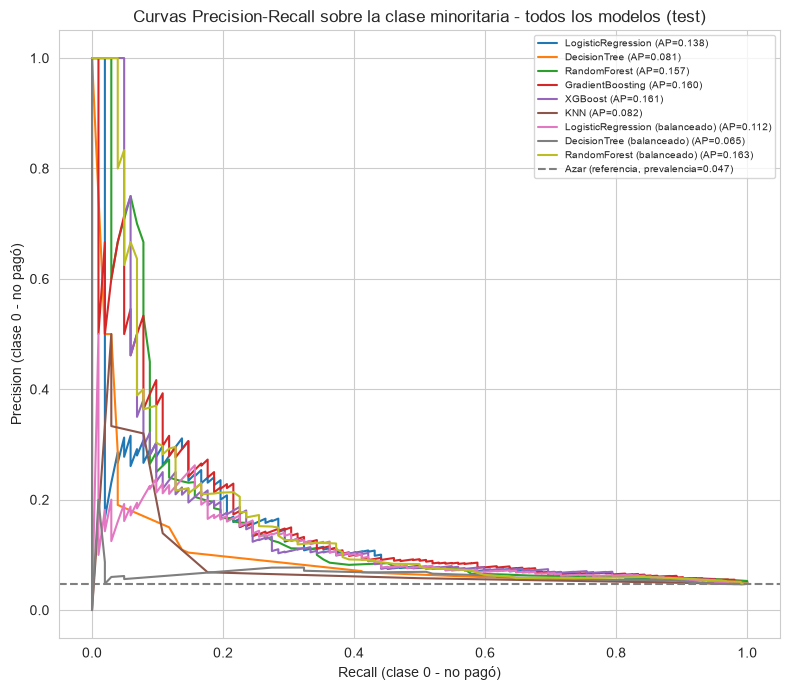

In [9]:
from sklearn.metrics import average_precision_score, precision_recall_curve

prevalencia_clase_0 = (y_test == 0).mean()

plt.figure(figsize=(8, 7))
for nombre, pipeline in pipelines_entrenados.items():
    y_score_clase_0 = pipeline.predict_proba(X_test)[:, 0]
    precision, recall, _ = precision_recall_curve(y_test, y_score_clase_0, pos_label=0)
    ap = average_precision_score(y_test, y_score_clase_0, pos_label=0)
    plt.plot(recall, precision, label=f"{nombre} (AP={ap:.3f})")

plt.axhline(prevalencia_clase_0, linestyle="--", color="gray",
            label=f"Azar (referencia, prevalencia={prevalencia_clase_0:.3f})")
plt.xlabel("Recall (clase 0 - no pagó)")
plt.ylabel("Precision (clase 0 - no pagó)")
plt.title("Curvas Precision-Recall sobre la clase minoritaria - todos los modelos (test)")
plt.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.savefig(REPORTS_FIGURAS / "curvas_precision_recall.png", dpi=150)
plt.show()

**Interpretación.** Acá la diferencia entre modelos se ve mucho más marcada que en la ROC: el average precision sobre la clase minoritaria queda bastante más cerca de la línea de azar (≈0.047, la prevalencia de la clase 0) que del techo (1.0) para todos los modelos — confirma que **ninguno de estos modelos resuelve bien el problema real del negocio** (detectar los créditos que no se van a pagar), aunque su AUC-ROC luzca razonable. Esta curva es la evidencia más honesta de que hay margen de mejora grande, más que la ROC.

## Barras comparando las 5 métricas (test), por modelo

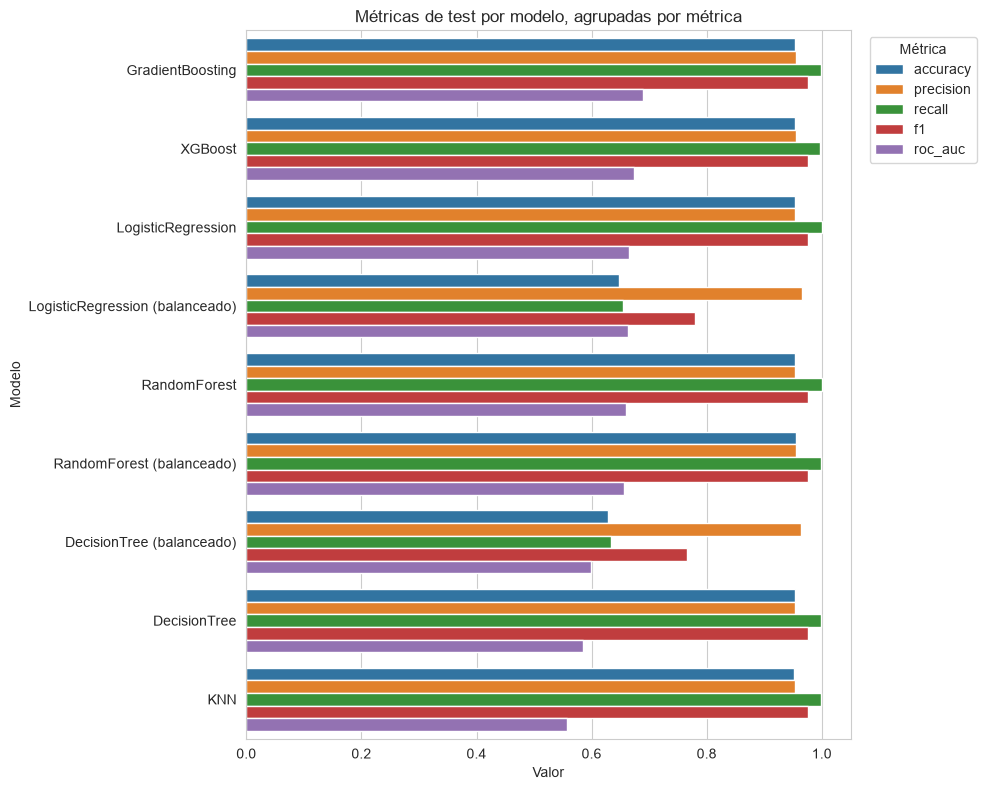

In [10]:
metricas_test = comparacion[["accuracy_test", "precision_test", "recall_test", "f1_test", "roc_auc_test"]]
metricas_test = metricas_test.rename(columns=lambda c: c.replace("_test", ""))
metricas_largas = metricas_test.reset_index().melt(id_vars="modelo", var_name="metrica", value_name="valor")

plt.figure(figsize=(10, 8))
sns.barplot(data=metricas_largas, y="modelo", x="valor", hue="metrica")
plt.title("Métricas de test por modelo, agrupadas por métrica")
plt.xlabel("Valor")
plt.ylabel("Modelo")
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(REPORTS_FIGURAS / "barras_metricas.png", dpi=150)
plt.show()

**Interpretación.** `accuracy`, `precision`, `recall` y `f1` se mantienen apretados arriba de 0.6 para casi todos los modelos (por el desbalance: son fáciles de inflar prediciendo mayoritariamente clase 1) — el único indicador que realmente separa a los modelos entre sí en este gráfico es `roc_auc`, la barra más corta y más variable de las cinco en todos los casos. Es la confirmación visual de por qué se eligió ROC-AUC como criterio de comparación.

## Matrices de confusión de los 3 mejores modelos (normalizadas por fila, test)

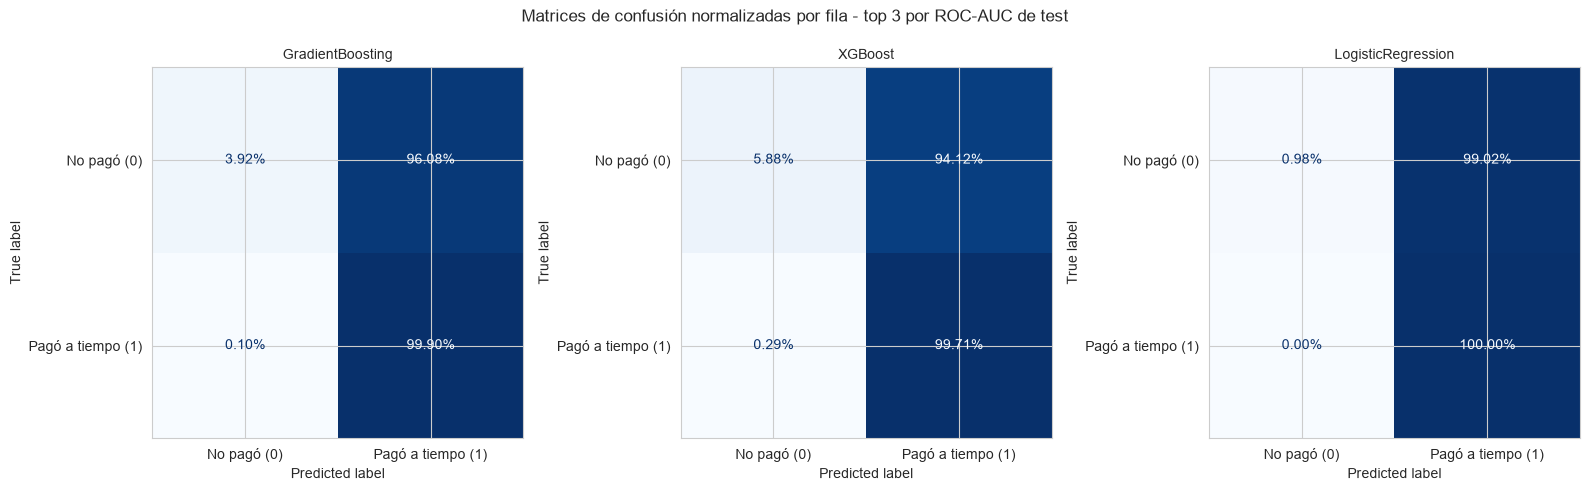

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, nombre in zip(axes, TOP_3):
    y_pred = pipelines_entrenados[nombre].predict(X_test)
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No pagó (0)", "Pagó a tiempo (1)"])
    disp.plot(ax=ax, cmap="Blues", values_format=".2%", colorbar=False)
    ax.set_title(nombre, fontsize=10)

plt.suptitle("Matrices de confusión normalizadas por fila - top 3 por ROC-AUC de test")
plt.tight_layout()
plt.savefig(REPORTS_FIGURAS / "matrices_confusion.png", dpi=150)
plt.show()

**Interpretación.** El problema queda a la vista con números concretos: sobre los créditos que **realmente** no se pagaron a tiempo (fila "No pagó (0)"), `GradientBoosting` acierta solo el 3.92%, `XGBoost` el 5.88%, y `LogisticRegression` apenas el 0.98% (casi nunca predice "no pagó"). El resto — 96%, 94% y 99% respectivamente — queda clasificado como "pagó a tiempo": son falsos negativos, el error más caro para el negocio, porque implica seguir otorgando el crédito a quien no lo va a pagar. Con el umbral de decisión por defecto (0.5), ninguno de estos tres modelos sirve todavía para el objetivo real del negocio, aunque su ROC-AUC luzca aceptable — es la misma alerta que ya daba la curva Precision-Recall, ahora con el desglose exacto por clase.

## Top 15 features más importantes - mejor modelo basado en árboles

`GradientBoosting` es el modelo basado en árboles con mejor ROC-AUC de test (por encima de `XGBoost`, `RandomForest` y `DecisionTree`), así que es el que se usa acá. Los nombres de las features son los reales que devuelve `get_feature_names_out()` del preprocesador ya ajustado dentro de ese pipeline.

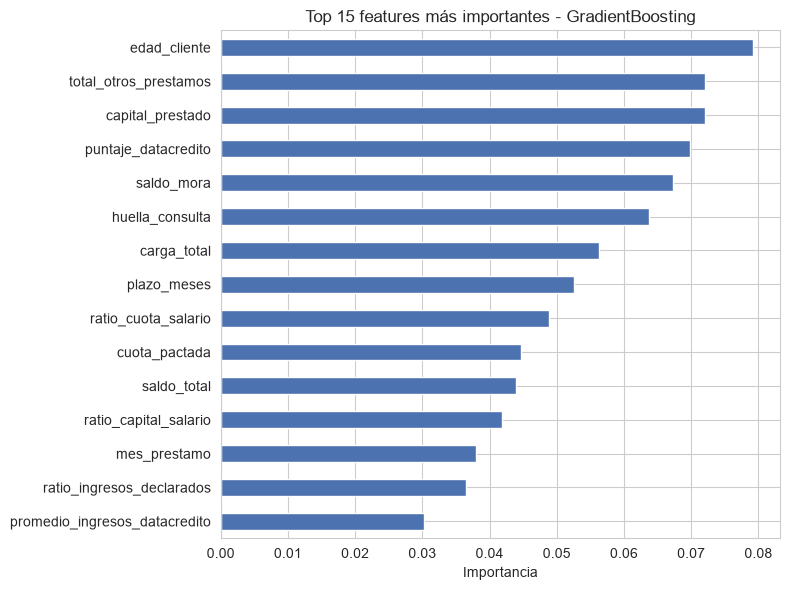

In [12]:
MEJOR_MODELO_ARBOL = "GradientBoosting"
pipeline_arbol = pipelines_entrenados[MEJOR_MODELO_ARBOL]

importancias = pipeline_arbol.named_steps["modelo"].feature_importances_
nombres_features = pipeline_arbol.named_steps["preprocesador"].get_feature_names_out()

top_15_importancias = pd.Series(importancias, index=nombres_features).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_15_importancias.sort_values().plot(kind="barh", color="#4C72B0")
plt.title(f"Top 15 features más importantes - {MEJOR_MODELO_ARBOL}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig(REPORTS_FIGURAS / "feature_importances.png", dpi=150)
plt.show()

**Interpretación.** No hay una sola feature dominante (el rango va de ≈0.03 a ≈0.08, sin ningún salto brusco como el que tenía `puntaje` antes de excluirla) — es exactamente lo esperable después de sacar la fuga: el modelo reparte la señal entre variables de negocio genuinas. De las 15 más importantes, 5 son features derivadas de `crear_features` (`carga_total`, `ratio_cuota_salario`, `ratio_capital_salario`, `mes_prestamo`, `ratio_ingresos_declarados`), lo que valida que la ingeniería de características aportó señal real y no quedó redundante con las columnas originales. Tienen sentido de negocio: `edad_cliente`, `total_otros_prestamos`, `capital_prestado` y `puntaje_datacredito` encabezan la lista, seguidas de cerca por `saldo_mora` y `huella_consulta` — todas señales de perfil de riesgo y capacidad de pago razonables para un modelo de crédito, no artefactos raros del dataset.

# Cierre del apartado de evaluación

## Tabla resumen final

Una fila por modelo, con las 5 métricas de test, más media y desvío del AUC en cross-validation — esta última solo para los 3 modelos que se corrieron en CV (el resto queda en blanco, a propósito: no se corrió CV para los otros 6 para no multiplicar el tiempo de cómputo sin necesidad, dado que ya estaban fuera del top 3 por AUC de test).

In [13]:
tabla_resumen = comparacion[["accuracy_test", "precision_test", "recall_test", "f1_test", "roc_auc_test"]].copy()
tabla_resumen.columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]

tabla_cv_indexada = tabla_cv.set_index("modelo")[["cv_auc_media", "cv_auc_std"]]
tabla_resumen = tabla_resumen.join(tabla_cv_indexada)
tabla_resumen = tabla_resumen.sort_values("roc_auc", ascending=False)

columnas_maximizar = ["accuracy", "precision", "recall", "f1", "roc_auc", "cv_auc_media"]
columnas_minimizar = ["cv_auc_std"]

estilo = (
    tabla_resumen.style
    .highlight_max(subset=columnas_maximizar, color="#c8e6c9")
    .highlight_min(subset=columnas_minimizar, color="#c8e6c9")
    .format("{:.4f}")
)
estilo

,accuracy,precision,recall,f1,roc_auc,cv_auc_media,cv_auc_std
modelo,,,,,,,
GradientBoosting,0.9536,0.9544,0.9990,0.9762,0.6890,0.7068,0.0208
XGBoost,0.9526,0.9552,0.9971,0.9757,0.6733,0.6561,0.0190
LogisticRegression,0.9531,0.9531,1.0000,0.9760,0.6652,0.6692,0.0298
LogisticRegression (balanceado),0.6484,0.9661,0.6538,0.7799,0.6637,nan,nan
RandomForest,0.9526,0.9526,1.0000,0.9757,0.6594,nan,nan
RandomForest (balanceado),0.9545,0.9548,0.9995,0.9767,0.6561,nan,nan
DecisionTree (balanceado),0.6289,0.9637,0.6343,0.7651,0.5981,nan,nan
DecisionTree,0.9526,0.9539,0.9985,0.9757,0.5852,nan,nan
KNN,0.9522,0.9526,0.9995,0.9755,0.5575,nan,nan


In [14]:
RUTA_TABLA_RESUMEN = RAIZ / "reports" / "tabla_resumen_modelos.csv"
tabla_resumen.to_csv(RUTA_TABLA_RESUMEN)
print("Tabla exportada a:", RUTA_TABLA_RESUMEN)

Tabla exportada a: /Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/reports/tabla_resumen_modelos.csv


## Selección del mejor modelo

**Elegido: `GradientBoosting`**, con **ROC-AUC de test** como criterio principal. Ya se justificó por qué esa métrica y no accuracy/precision/recall/f1: con 95%/4.75% de desbalance, esas cuatro se inflan solas prediciendo mayoritariamente la clase mayoritaria (se vio literalmente en la tabla y en las barras comparativas), mientras que ROC-AUC no depende del umbral ni de la proporción de clases.

**Diferencia contra el segundo (`XGBoost`) — y si alcanza.** En test, GradientBoosting saca 0.6890 contra 0.6733 de XGBoost: una diferencia de **0.0157**. Comparada contra el desvío de la cross-validation de GradientBoosting (±0.0208) o el de XGBoost (±0.0190), esa diferencia de test **es más chica que el ruido de un solo fold** — no alcanza para decir "gana clarísimo" mirando solo el test. Pero la media de CV cuenta una historia más sólida: GradientBoosting promedia 0.7068 en 5 folds contra 0.6561 de XGBoost, una diferencia de **0.0507** — ahí sí, mayor que el desvío de cualquiera de los dos modelos. La elección se apoya en la CV, no en el número de test aislado, que por sí solo no hubiera sido concluyente.

**Qué error comete más, y cuál es más caro.** Tomando como "positivo" la clase de interés del negocio (`0` = no pagó, el evento que hay que detectar): sobre los 102 créditos del test que realmente no se pagaron a tiempo, el modelo predice erróneamente "pagó a tiempo" en 98 (falso negativo bajo esa convención) y acierta en solo 4. En la otra dirección, de los créditos que sí se pagaron, predice erróneamente "no pagó" en apenas 2 casos. El modelo comete casi exclusivamente el error caro: **falsos negativos de no-pago** (seguir otorgando crédito a quien no va a pagar), no falsos positivos. En un problema de riesgo crediticio ese es, sin dudas, el error más costoso — un falso positivo (rechazar a un buen pagador) es una oportunidad de negocio perdida; un falso negativo es una pérdida de capital real. **Con el umbral por defecto (0.5), este modelo no está resolviendo el problema de negocio todavía** — el umbral operativo tendría que bajarse (aceptar más falsos positivos) para capturar más verdaderos no-pagos, a costa de rechazar más buenos pagadores; ese ajuste de umbral queda fuera del alcance de este notebook, pero es el siguiente paso obligado antes de llevar esto a producción.

**Features más importantes y sentido de negocio.** `edad_cliente`, `total_otros_prestamos`, `capital_prestado` y `puntaje_datacredito` encabezan el ranking de importancia, seguidas de `saldo_mora` y `huella_consulta` — todas señales de perfil de riesgo y capacidad de pago razonables. Además, 5 de las 15 features más importantes son derivadas de `crear_features` (`carga_total`, `ratio_cuota_salario`, `ratio_capital_salario`, `mes_prestamo`, `ratio_ingresos_declarados`), lo que confirma que la ingeniería de características de esta etapa aportó señal real, no quedó redundante con las columnas originales.

## Chequeo obligatorio de fuga

El mejor modelo (`GradientBoosting`) tiene **ROC-AUC de test = 0.6890**, muy por debajo de 0.95. **No hace falta frenar ni revisar de nuevo por fuga** — lo digo explícitamente en vez de solo omitirlo: un AUC de 0.95+ hubiera sido motivo de sospecha (como pasó con `puntaje`, que llegó a AUC=1.0 y se excluyó), pero 0.69 es un desempeño modesto, consistente con variables de negocio genuinas y sin ninguna señal de que se haya colado información del futuro.

# Guardar el modelo ganador

Se serializa el pipeline completo (preprocesador + `GradientBoostingClassifier`) con `joblib`, junto con un JSON de metadata para que el avance de despliegue sepa qué modelo es, cómo se entrenó, y qué columnas espera.

In [15]:
import joblib

MEJOR_MODELO = "GradientBoosting"
pipeline_ganador = pipelines_entrenados[MEJOR_MODELO]

RUTA_MODELOS = RAIZ / "models"
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_PKL = RUTA_MODELOS / "modelo_final.pkl"

joblib.dump(pipeline_ganador, RUTA_PKL)
print("Modelo guardado en:", RUTA_PKL)

Modelo guardado en: /Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/models/modelo_final.pkl


## Metadata del modelo

In [16]:
import json
from datetime import datetime, timezone

estimador_ganador = pipeline_ganador.named_steps["modelo"]
metricas_test_ganador = comparacion.loc[MEJOR_MODELO, ["accuracy_test", "precision_test", "recall_test", "f1_test", "roc_auc_test"]].to_dict()

metadata = {
    "nombre_algoritmo": type(estimador_ganador).__name__,
    "hiperparametros": estimador_ganador.get_params(),
    "fecha_entrenamiento": datetime.now(timezone.utc).isoformat(),
    "metricas_test": {k: round(v, 4) for k, v in metricas_test_ganador.items()},
    "columnas_entrada_esperadas": list(X_train.columns),
    "columnas_excluidas_por_fuga": COLUMNAS_EXCLUIDAS_POR_FUGA,
}

RUTA_METADATA = RUTA_MODELOS / "modelo_final_metadata.json"
with open(RUTA_METADATA, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)

print("Metadata guardada en:", RUTA_METADATA)
metadata

Metadata guardada en: /Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/models/modelo_final_metadata.json


{'nombre_algoritmo': 'GradientBoostingClassifier',
 'hiperparametros': {'ccp_alpha': 0.0,
  'criterion': 'deprecated',
  'init': None,
  'learning_rate': 0.1,
  'loss': 'log_loss',
  'max_depth': 3,
  'max_features': None,
  'max_leaf_nodes': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'n_estimators': 100,
  'n_iter_no_change': None,
  'random_state': 42,
  'subsample': 1.0,
  'tol': 0.0001,
  'validation_fraction': 0.1,
  'verbose': 0,
  'warm_start': False},
 'fecha_entrenamiento': '2026-08-27T13:02:00.450601+00:00',
 'metricas_test': {'accuracy_test': 0.9536,
  'precision_test': 0.9544,
  'recall_test': 0.999,
  'f1_test': 0.9762,
  'roc_auc_test': 0.689},
 'columnas_entrada_esperadas': ['tipo_credito',
  'capital_prestado',
  'plazo_meses',
  'edad_cliente',
  'tipo_laboral',
  'salario_cliente',
  'total_otros_prestamos',
  'cuota_pactada',
  'puntaje_datacredito',
  'cant_creditosvigentes',
  'huell

## Verificación: el .pkl cargado predice exactamente igual que el modelo en memoria

In [17]:
modelo_cargado = joblib.load(RUTA_PKL)

primeras_5 = X_test.head(5)
pred_memoria = pipeline_ganador.predict(primeras_5)
pred_cargado = modelo_cargado.predict(primeras_5)

proba_memoria = pipeline_ganador.predict_proba(primeras_5)
proba_cargado = modelo_cargado.predict_proba(primeras_5)

print("Predicciones en memoria:", pred_memoria)
print("Predicciones del .pkl:  ", pred_cargado)
print("¿Coinciden las clases predichas?:", (pred_memoria == pred_cargado).all())
print("¿Coinciden las probabilidades exactamente?:", np.array_equal(proba_memoria, proba_cargado))

Predicciones en memoria: [1 1 1 1 1]
Predicciones del .pkl:   [1 1 1 1 1]
¿Coinciden las clases predichas?: True
¿Coinciden las probabilidades exactamente?: True


## Tamaño del archivo y confirmación de que `models/` no está en `.gitignore`

In [18]:
peso_mb = RUTA_PKL.stat().st_size / (1024 ** 2)
print(f"Peso de modelo_final.pkl: {peso_mb:.2f} MB")
if peso_mb > 50:
    print("¡ATENCIÓN! Supera los 50 MB, avisar antes de commitear.")
else:
    print("Por debajo de 50 MB, se puede commitear sin problema de tamaño.")

gitignore_contenido = (RAIZ / ".gitignore").read_text()
print("\n¿'models' aparece en .gitignore?:", "models" in gitignore_contenido)

Peso de modelo_final.pkl: 0.14 MB
Por debajo de 50 MB, se puede commitear sin problema de tamaño.

¿'models' aparece en .gitignore?: False
